In [7]:
import librosa
import os
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import re
from itertools import product
import pyloudnorm as pdn
import IPython.display as ipd
from pathlib import Path
import zipfile

Splits audio on samples given in dictionary.

Plots waveforms with red line at split point.

Saves single graph to graphs folder for report.

Zips files.

In [8]:
dpi=300

In [9]:
project_dir = Path.cwd().parent

norm_path = project_dir / 'data' / 'trimmed' / 'lufs_normalised'
split_path = project_dir / 'data' / 'trimmed' / 'split'
graphs = project_dir / 'graphs' / 'wave'


In [10]:
os.makedirs(split_path, exist_ok=True)
os.makedirs(graphs, exist_ok=True)

In [11]:
split_idxs = {
    'field1mflyby1_norm.wav': 180000,
    'field1mflyby2_norm.wav': 145000,
    'field3mflyby1_norm.wav': 130000,
    'field3mflyby2_norm.wav': None,
    'field5mflyby1_norm.wav': 250000,
    'field5mflyby2_norm.wav': 200000,
    'garden1mflyby1_norm.wav': 100000,
    'garden1mflyby2_norm.wav': None,
    'garden3mflyby1_norm.wav': None,
    'garden3mflyby2_norm.wav': None,
    'garden5mflyby1_norm.wav': None,
    'garden5mflyby2_norm.wav': None, 
}

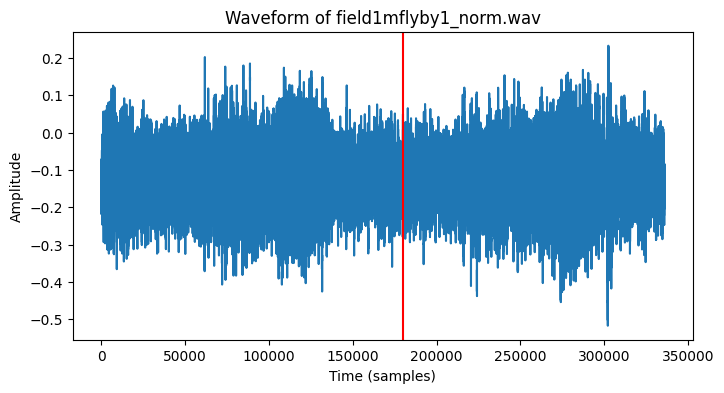

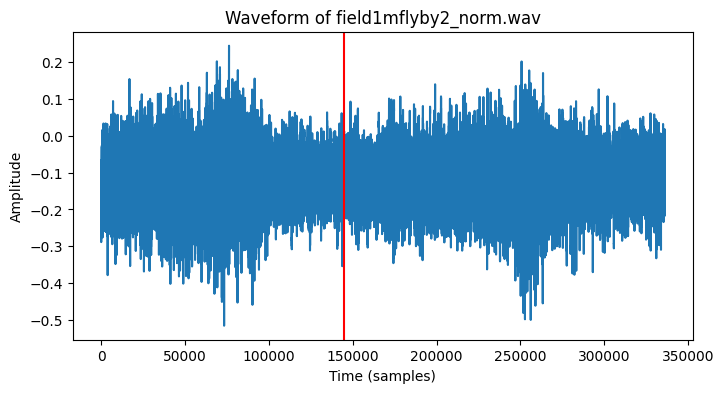

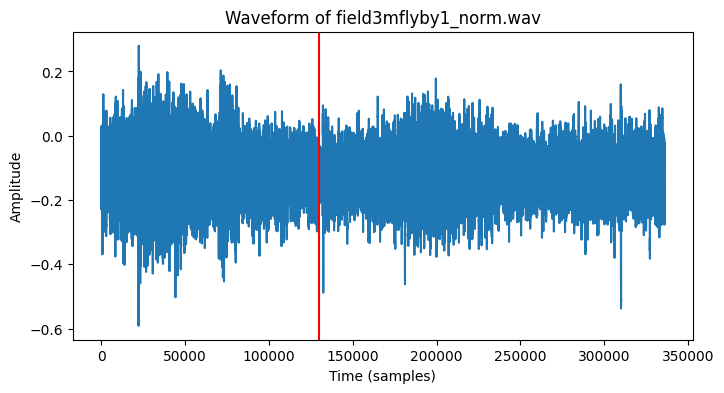

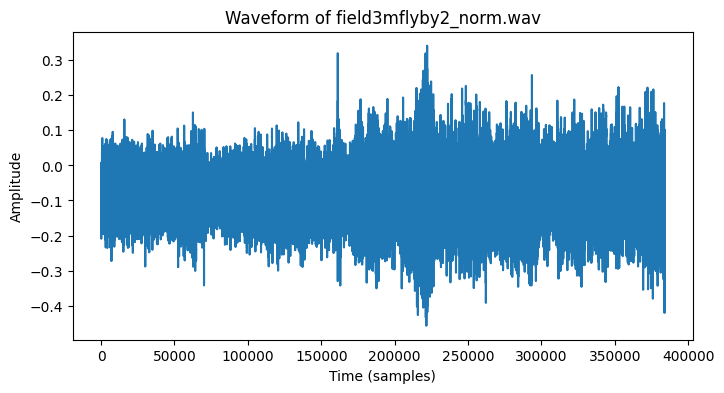

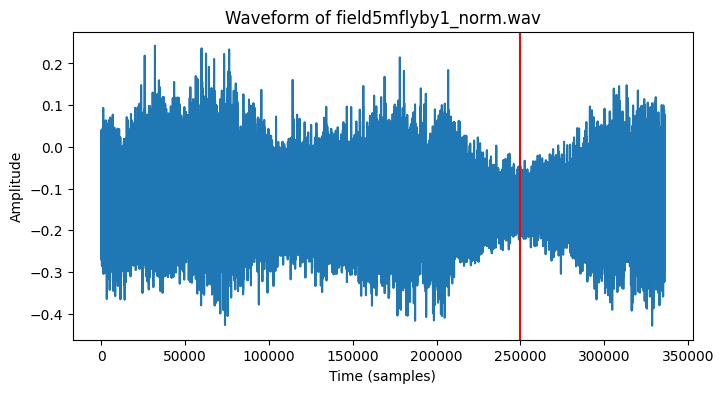

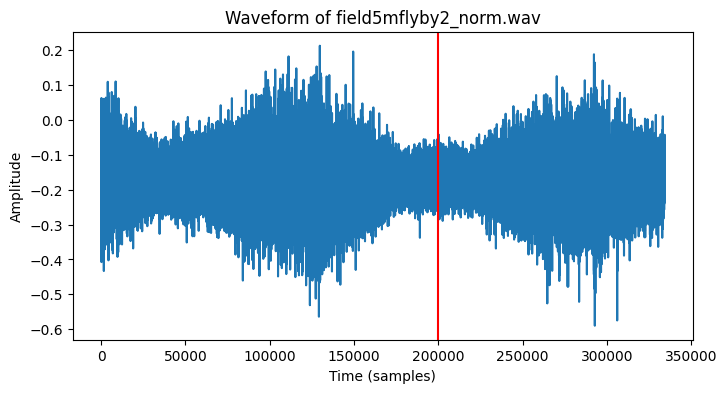

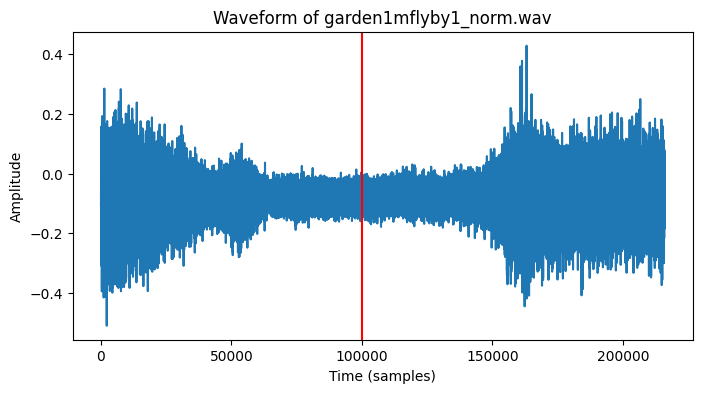

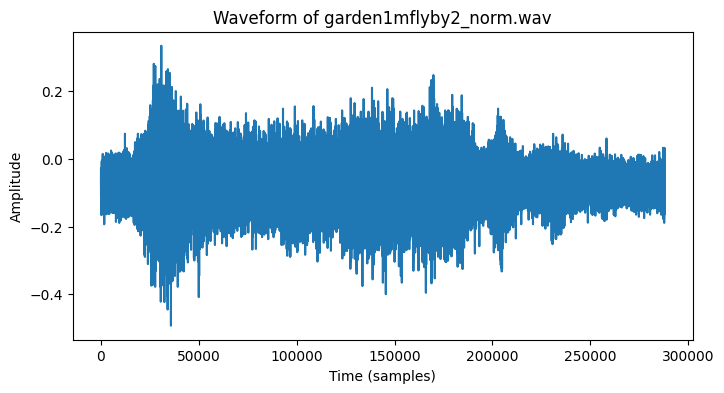

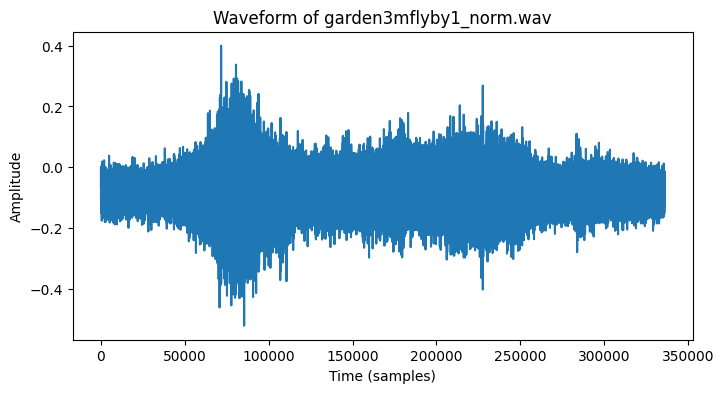

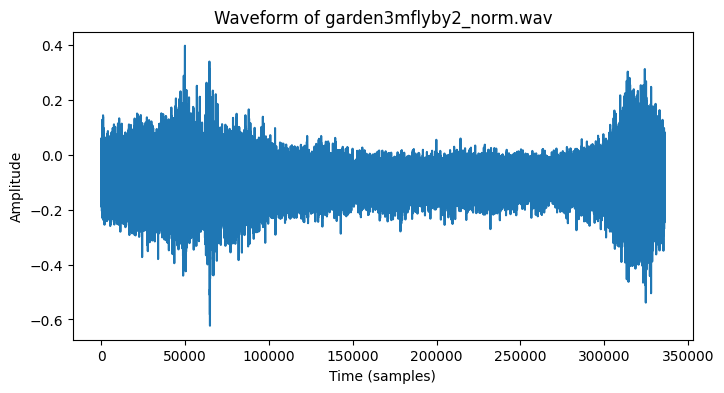

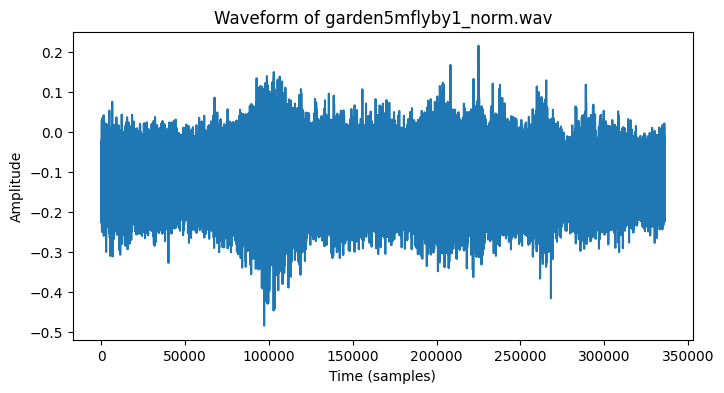

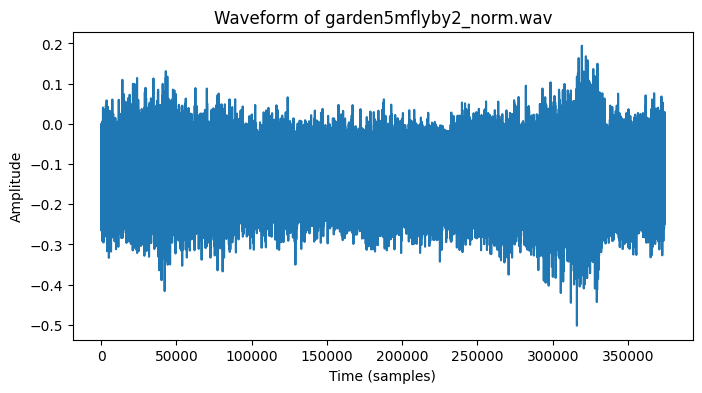

In [12]:
for fname in os.listdir(norm_path):
    if fname.endswith('.wav') and ('flyby' in fname):
        full_fname = os.path.join(norm_path, fname)
        snd, sr = librosa.load(full_fname, sr=None)

        split_index = split_idxs[fname]
        
        t = np.arange(len(snd)) / sr
        
        fig, ax = plt.subplots(figsize=(8, 4))
        
        ax.plot(snd)
        ax.set_xlabel("Time (samples)")
        ax.set_ylabel("Amplitude")
        ax.set_title(f"Waveform of {fname}")
        
        if split_index is not None:
            ax.axvline(split_index, c='r')
        
        if fname == 'field5mflyby2_norm.wav':
            f = graphs / 'segmented_audio.png'
            plt.savefig(f, dpi=dpi, bbox_inches='tight')

        plt.show()
        
        base = fname.split('.')[0]
        split_index = split_idxs[fname]
        if split_index is None:
            continue

        s1 = snd[:split_index]
        s2 = snd[split_index:]

        p1 = os.path.join(split_path, base + '_1.wav')
        p2 = os.path.join(split_path, base + '_2.wav')

        sf.write(p1, s1, sr)
        sf.write(p2, s2, sr)

In [13]:
zip_path = project_dir / 'data' / 'trimmed' / 'split.zip'

files_zipped = []

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(split_path):
        if fname.endswith('.wav'):
            fpath = split_path / fname
            zf.write(fpath, arcname=f'split/{fname}')
            files_zipped.append(fname)
            print(f'Zipped: {fname}')

print(f'\nDone. {len(files_zipped)} files zipped to {zip_path}')

Zipped: field1mflyby1_norm_1.wav
Zipped: field1mflyby1_norm_2.wav
Zipped: field1mflyby2_norm_1.wav
Zipped: field1mflyby2_norm_2.wav
Zipped: field3mflyby1_norm_1.wav
Zipped: field3mflyby1_norm_2.wav
Zipped: field5mflyby1_norm_1.wav
Zipped: field5mflyby1_norm_2.wav
Zipped: field5mflyby2_norm_1.wav
Zipped: field5mflyby2_norm_2.wav
Zipped: garden1mflyby1_norm_1.wav
Zipped: garden1mflyby1_norm_2.wav

Done. 12 files zipped to D:\UCD COMP SCI\PROJECT_TEST ONLY\data\trimmed\split.zip
